In [1]:
# Step 1: Import library dasar
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

# Step 2: Load dataset
df = pd.read_csv('smart_lighting_dataset_2024.csv')
print("Data sample:")
display(df.head())

print("\nInformasi dataset:")
df.info()


Data sample:


,timestamp,zone_id,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,day_of_week,time_of_day,weather_condition,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,adjusted_light_intensity,energy_consumption_kwh,lighting_action_class
0,2024-01-01 00:00:00,3,0.00,0,22.08,7,Monday,Night,Cloudy,0,3.83,3.27,26.0,4.54,54.40,1.144,0
1,2024-01-01 00:43:00,3,35.78,0,19.19,6,Monday,Night,Cloudy,0,4.61,1.50,18.9,2.42,89.75,2.069,1
2,2024-01-01 01:27:00,7,0.00,0,27.78,9,Monday,Night,Clear,0,4.21,2.51,27.6,2.85,82.25,1.687,1
3,2024-01-01 02:11:00,2,0.00,1,33.11,16,Monday,Night,Foggy,0,6.16,0.34,23.1,2.45,72.57,1.631,1
4,2024-01-01 02:55:00,4,0.00,1,27.07,11,Monday,Night,Clear,0,5.72,1.52,26.4,3.49,78.79,1.737,1



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   timestamp                   12000 non-null  object 
 1   zone_id                     12000 non-null  int64  
 2   ambient_light_lux           12000 non-null  float64
 3   motion_detected             12000 non-null  int64  
 4   temperature_celsius         12000 non-null  float64
 5   occupancy_count             12000 non-null  int64  
 6   day_of_week                 12000 non-null  object 
 7   time_of_day                 12000 non-null  object 
 8   weather_condition           12000 non-null  object 
 9   special_event_flag          12000 non-null  int64  
 10  energy_price_per_kwh        12000 non-null  float64
 11  prev_hour_energy_usage_kwh  12000 non-null  float64
 12  traffic_density             12000 non-null  float64
 13  avg_pedestr

In [2]:
# ===============================
# Step Pembersihan data
# ===============================

# Hapus duplikasi
df.drop_duplicates(inplace=True)

# Isi missing value untuk kolom numerik
if 'ambient_light_lux' in df.columns:
    df['ambient_light_lux'].fillna(df['ambient_light_lux'].mean(), inplace=True)

# Isi missing value untuk kolom kategorikal
for col in ['day_of_week', 'time_of_day', 'weather_condition', 'lighting_action_class']:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Cek info dataset setelah pembersihan
print("\nSetelah pembersihan:")
df.info()



Setelah pembersihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   timestamp                   12000 non-null  object 
 1   zone_id                     12000 non-null  int64  
 2   ambient_light_lux           12000 non-null  float64
 3   motion_detected             12000 non-null  int64  
 4   temperature_celsius         12000 non-null  float64
 5   occupancy_count             12000 non-null  int64  
 6   day_of_week                 12000 non-null  object 
 7   time_of_day                 12000 non-null  object 
 8   weather_condition           12000 non-null  object 
 9   special_event_flag          12000 non-null  int64  
 10  energy_price_per_kwh        12000 non-null  float64
 11  prev_hour_energy_usage_kwh  12000 non-null  float64
 12  traffic_density             12000 non-null  float64
 13  avg_pedes

/tmp/ipython-input-2822719778.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ambient_light_lux'].fillna(df['ambient_light_lux'].mean(), inplace=True)
/tmp/ipython-input-2822719778.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [3]:
# Step 3: Pilih kolom yang digunakan
selected_features = ['ambient_light_lux', 'motion_detected', 'day_of_week', 'time_of_day', 'weather_condition']
target = 'lighting_action_class'

data = df[selected_features + [target]]
print("Fitur yang digunakan:", selected_features)
display(data.head())


Fitur yang digunakan: ['ambient_light_lux', 'motion_detected', 'day_of_week', 'time_of_day', 'weather_condition']


,ambient_light_lux,motion_detected,day_of_week,time_of_day,weather_condition,lighting_action_class
0,0.00,0,Monday,Night,Cloudy,0
1,35.78,0,Monday,Night,Cloudy,1
2,0.00,0,Monday,Night,Clear,1
3,0.00,1,Monday,Night,Foggy,1
4,0.00,1,Monday,Night,Clear,1


In [4]:
# Step 4: Encode kolom kategorikal jadi angka
le = LabelEncoder()
for col in ['day_of_week', 'time_of_day', 'weather_condition', 'lighting_action_class']:
    data[col] = le.fit_transform(data[col])

# Pisahkan fitur & target
X = data[selected_features]
y = data[target]

# Split data ke training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Ukuran data training:", X_train.shape)
print("Ukuran data testing :", X_test.shape)


Ukuran data training: (9600, 5)
Ukuran data testing : (2400, 5)


/tmp/ipython-input-3878853432.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = le.fit_transform(data[col])
/tmp/ipython-input-3878853432.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = le.fit_transform(data[col])
/tmp/ipython-input-3878853432.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [5]:
# Step 5: Buat dan latih model AI
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model berhasil dilatih!")


✅ Model berhasil dilatih!


Akurasi: 0.7358333333333333

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62       802
           1       0.85      0.88      0.87      1402
           2       0.23      0.18      0.20       196

    accuracy                           0.74      2400
   macro avg       0.57      0.56      0.56      2400
weighted avg       0.73      0.74      0.73      2400



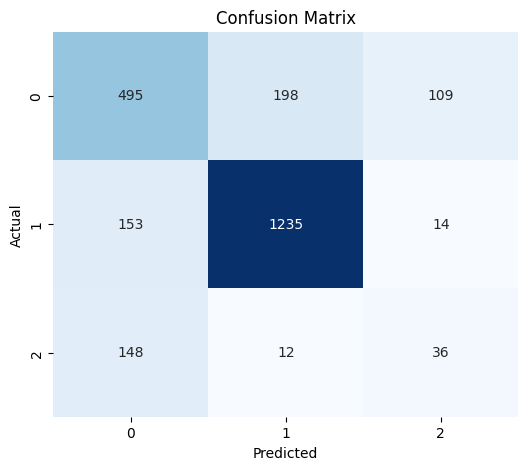

In [6]:
# ===============================
# Step Evaluasi Model
# ===============================
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Akurasi:", acc)

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [7]:
# ======================================================
# Step 7: Simpan dataset & model ML
# ======================================================
# Folder untuk hasil
os.makedirs("processed_data", exist_ok=True)

# Simpan dataset hasil preprocessing
processed_data = pd.concat([X, y], axis=1)
csv_filename = "processed_data/smart_lighting_processed_2024.csv"
processed_data.to_csv(csv_filename, index=False)
print(f"✅ Dataset preprocessing disimpan: {csv_filename}")

# Simpan model ML untuk Django
model_filename = "processed_data/smart_lighting_model.pkl"
joblib.dump(model, model_filename)
print(f"✅ Model ML tersimpan: {model_filename}")


✅ Dataset preprocessing disimpan: processed_data/smart_lighting_processed_2024.csv
✅ Model ML tersimpan: processed_data/smart_lighting_model.pkl


In [8]:
import joblib
import os
from google.colab import files

# Misal model sudah fit
model_filename = "smart_lighting_model.pkl"
joblib.dump(model, model_filename)

# Download ke komputer lokal
files.download(model_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

# Path file model
model_filename = "processed_data/smart_lighting_model.pkl"

# Load model
model = joblib.load(model_filename)

# Lihat tipe model
print("Tipe model:", type(model))

# Kalau model scikit-learn, bisa cek atribut penting misal:
if hasattr(model, "feature_importances_"):
    print("Feature importances:", model.feature_importances_)

if hasattr(model, "classes_"):
    print("Kelas target:", model.classes_)

# Bisa juga lihat beberapa parameter model
if hasattr(model, "get_params"):
    print("Parameter model:")
    print(model.get_params())


Tipe model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Feature importances: [0.70306445 0.10690941 0.04304786 0.0667329  0.08024537]
Kelas target: [0 1 2]
Parameter model:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
